In [52]:
import numpy as np
import matplotlib.pyplot as plt
import librosa as lb
import IPython.display as ipd
from scipy.signal import medfilt
import scipy.io as sio
import math
import pyaudio
import wave
import ipywidgets as widgets
import soundfile as sf
import io
import audioop
import time
import scipy


1.0


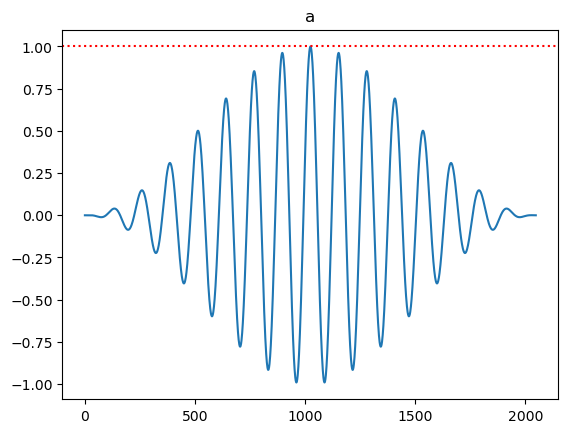

In [53]:
sr = 22050
dur = 30
signal = np.cos(np.pi * (1/64) * np.arange(0, sr*dur))
L = 2048
Hs = L//4
window = scipy.signal.windows.hann(L, sym=False)
plt.plot(signal[0:L] * window)
plt.axhline(1, color='r', linestyle="dotted")
plt.title("a")
print(np.max(signal[0:L] * window))

1.0


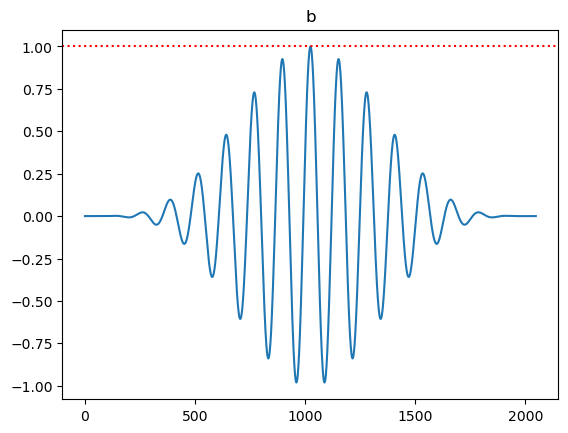

In [54]:
plt.plot(signal[0:L] * window * window)
plt.axhline(1, color='r', linestyle="dotted")

plt.title("b")
print(np.max(signal[0:L] * window * window))

In [55]:
def calc_sum_squared_window(window, hop_length):
    '''
    Calculates the denominator term for computing synthesis frames.
    
    Inputs
    window: array specifying the window used in FFT analysis
    hop_length: the synthesis hop size in samples
    
    Returns an array specifying the normalization factor.
    '''
    assert (len(window) % hop_length == 0), "Hop length does not divide the window evenly."
    
    numShifts = len(window) // hop_length
    den = np.zeros_like(window)
    for i in range(numShifts):
        den += np.roll(np.square(window), i*hop_length)
        
    return den

[1.5 1.5 1.5 ... 1.5 1.5 1.5]


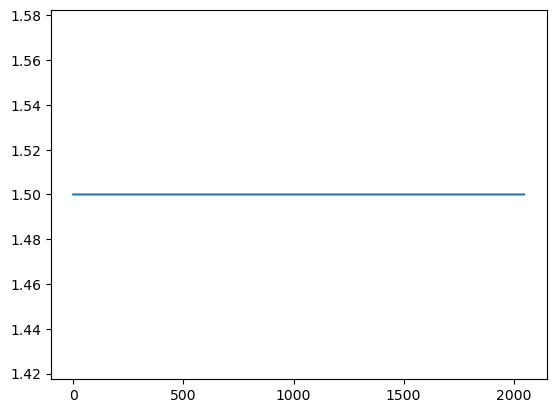

In [56]:
den = calc_sum_squared_window(window, Hs)
plt.plot(den)
print(den)

0.6666666666666666


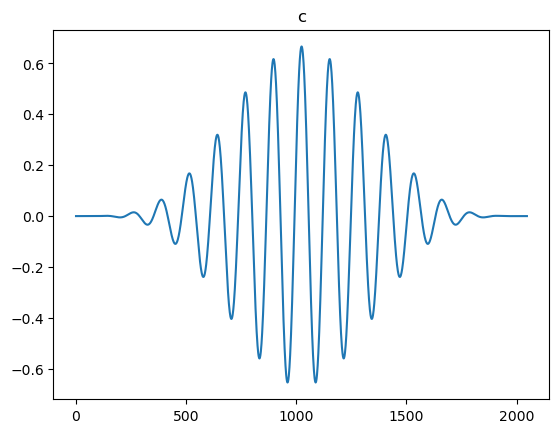

In [57]:
plt.plot(signal[0:L] * window * window / calc_sum_squared_window(window, Hs))
plt.title("c")
print(np.max(signal[0:L] * window * window / calc_sum_squared_window(window, Hs)))

In [58]:
shift_add = np.zeros_like(signal)
for i in range(0, len(signal)-L, Hs):
    shift_add[i:i+L] += signal[i:i+L] * window * window / calc_sum_squared_window(window, Hs)

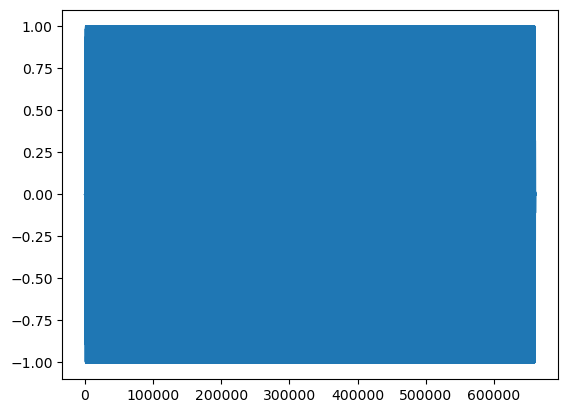

In [59]:
plt.plot(shift_add)

In [60]:
np.max(shift_add)

1.0

In [80]:
def calc_sum_squared_window(window, hop_length):
    '''
    Calculates the denominator term for computing synthesis frames.
    
    Inputs
    window: array specifying the window used in FFT analysis
    hop_length: the synthesis hop size in samples
    
    Returns an array specifying the normalization factor.
    '''
    assert (len(window) % hop_length == 0), "Hop length does not divide the window evenly."
    
    numShifts = len(window) // hop_length
    den = np.zeros_like(window)
    for i in range(numShifts):
        den += np.roll(np.square(window), i*hop_length)
        
    return den

def calc_sum_squared_window_any(window, hop_length):
    """
    Calculates the denominator for OLA normalization for any hop length.
    Unlike the original version, it does not require hop_length to divide len(window).
    """
    win_len = len(window)
    max_offset = win_len + hop_length
    den = np.zeros(max_offset)

    for shift in range(0, max_offset, hop_length):
        start = shift
        end = shift + win_len
        den[start:end] += window**2

    return den[:win_len]

def estimateIF(S, sr, hop_samples):
    '''
    Estimates the instantaneous frequencies in a STFT matrix.
    
    Inputs
    S: the STFT matrix, should only contain the lower half of the frequency bins
    sr: sampling rate
    hop_samples: the hop size of the STFT analysis in samples
    
    Returns a matrix containing the estimated instantaneous frequency at each time-frequency bin.
    This matrix should contain one less column than S.
    '''
    hop_sec = hop_samples / sr
    fft_size = (S.shape[0] - 1) * 2
    w_nom = np.arange(S.shape[0]) * sr / fft_size * 2 * np.pi
    w_nom = w_nom.reshape((-1,1))    
    unwrapped = np.angle(S[:,1:]) - np.angle(S[:,0:-1]) - w_nom * hop_sec
    wrapped = (unwrapped + np.pi) % (2 * np.pi) - np.pi
    w_if = w_nom + wrapped / hop_sec
    return w_if

def invert_stft(S, hop_length, window):
    '''
    Reconstruct a signal from a modified STFT matrix.
    
    Inputs
    S: modified STFT matrix
    hop_length: the synthesis hop size in samples
    window: an array specifying the window used for FFT analysis
    
    Returns a time-domain signal y whose STFT is closest to S in squared error distance.
    '''
    
    L = len(window)
    
    # construct full stft matrix
    fft_size = (S.shape[0] - 1) * 2
    Sfull = np.zeros((fft_size, S.shape[1]), dtype=np.complex64)
    Sfull[0:S.shape[0],:] = S
    Sfull[S.shape[0]:,:] = np.conj(np.flipud(S[1:fft_size//2,:]))
    
    # compute inverse FFTs
    frames = np.zeros_like(Sfull)
    for i in range(frames.shape[1]):
        frames[:,i] = np.fft.ifft(Sfull[:,i])
    frames = np.real(frames) # remove imaginary components due to numerical roundoff
    
    # synthesis frames
    den = calc_sum_squared_window(window, hop_length)
    frames = frames * window.reshape((-1,1)) / den.reshape((-1,1))
    
    # reconstruction
    y = np.zeros(hop_length*(frames.shape[1]-1) + L)
    for i in range(frames.shape[1]):
        offset = i * hop_length
        y[offset:offset+L] += frames[:,i]
    
    return y

def harmonic_percussive_separation(x, sr=22050, fft_size = 2048, hop_length=512, lh=6, lp=6):
    window = np.hanning(fft_size)
    X = lb.core.stft(x, n_fft=fft_size, hop_length=512, window=window, center=False)
    Y = np.abs(X)
    Yh = medfilt(Y, (1, 2*lh+1))
    Yp = medfilt(Y, (2*lp+1, 1))
    Mh = (Yh > Yp)
    Mp = np.logical_not(Mh)
    Xh = X * Mh
    Xp = X * Mp
    xh = invert_stft(Xh, hop_length, window)
    xp = invert_stft(Xp, hop_length, window)
    
    return xh, xp, Xh, Xp

def float2pcm(sig, dtype='int16'):
    # assert sig <= 1 and sig >= -1, "Data must be normalized between -1.0 and 1.0"
    sig = np.asarray(sig)
    dtype = np.dtype(dtype)
    i = np.iinfo(dtype)
    abs_max = 2 ** (i.bits - 1)
    offset = i.min + abs_max
    return (sig * abs_max + offset).clip(i.min, i.max).astype(dtype)

# @jit(nopython=True)
# def _stft_frames(xh, window, Ha_lookup, L):
#     n_frames = int(np.round((len(xh) / Ha_lookup))) + 1
#     frames = np.zeros((n_frames, L), dtype=np.float64)
#     for i in range(n_frames):
#         start = i * Ha_lookup
#         end = start + L
#         if end > len(xh):
#             break
#         frames[i, :] = xh[start:end] * window
#     return frames

# def manual_stft_numba(xh, beta, L=2048, sr=22050):
#     Ha_lookup = int(round(beta * L))
#     window = scipy.signal.windows.hann(L, sym=False)
#     frames = _stft_frames(xh, window, Ha_lookup, L)
#     # print(f"COLA: {scipy.signal.check_COLA(window, nperseg=L, noverlap=int(L - Hs))}")
#     S_lookup = np.fft.rfft(frames, axis=1).T  # shape: (freq_bins, frames)
#     # print(f"S_lookup: {S_lookup.shape}")
#     # print(f"librosa shape: {lb.core.stft(xh, n_fft=L, hop_length=Ha_lookup, window=window).shape}")
#     return S_lookup

def manual_stft_numpy(xh, beta, L=2048, sr=22050):
        Ha_lookup = int(round(beta * L))
        window = scipy.signal.windows.hann(L, sym=False)
        n_frames = int(np.round((len(xh) - L) / Ha_lookup))
        k_bins = 1 + L // 2
        S_lookup = np.zeros((k_bins, n_frames), dtype=np.complex64)
        for i in range(n_frames):
            start = i * Ha_lookup
            end = start + L
            if end > len(xh):
                break
            S_lookup[:, i] = np.fft.rfft(xh[start:end] * window)
        return S_lookup
    

volume_ratios = []
volume_ratios_db = []
num_iterations = 1

# # SIMPLE CASE: ARRAY OF ONES
frequency = 440
sample_rate = 22050
duration = 30.0  # 1 second
# signal = np.ones(int(duration*sample_rate))

# # bin_idx = 41
# t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)
# signal = np.cos(2 * np.pi * frequency * t)

signal = np.cos(np.pi * (1/64) * np.arange(0, sample_rate*duration))
# # Randomly select a file from samples/genres_original/<genre>/<song>
# genres_dir = "samples/genres_original"
# genres = [g for g in os.listdir(genres_dir) if os.path.isdir(os.path.join(genres_dir, g))]
# chosen_genre = np.random.choice(genres)
# genre_path = os.path.join(genres_dir, chosen_genre)
# songs = [s for s in os.listdir(genre_path) if os.path.isfile(os.path.join(genre_path, s))]
# file_name = os.path.join(genre_path, np.random.choice(songs))

# file_name = '/Users/server/Documents/GitHub/DSP_FinalProject/samples/genres_original/pop/pop.00015.wav'
# audio_data, audio_sr = lb.load(file_name)
audio_data = signal
audio_sr = 22050

# Constants
CHUNK = L = 2048
L_ola = 256
Hs = L // 4
Hs_ola = L_ola // 2
alpha = 1.00
window = scipy.signal.windows.hann(L, sym=False)
window_ola = scipy.signal.windows.hann(L_ola, sym=False)
output_buffer = np.zeros(int(L))
normalization = np.zeros(int(L))
prev_fft = None
prev_phase = np.zeros(L//2 + 1)
runtimes = []

pos = 0
pos_ola = 0

# Determines the phase vocoder look-up analysis hopsize e.g. beta = 0.125 is 12.5% overlap
beta = 0.25
xh, xp, _, _ = harmonic_percussive_separation(x=audio_data, sr=audio_sr)

omega_nom = np.arange(L//2 + 1) * 2 *np.pi * audio_sr / L


#Phase vocoder Look-up
Ha_lookup = int(round((beta)*L))
den = calc_sum_squared_window(window, Hs)

S_lookup = manual_stft_numpy(xh, beta, L=L, sr=audio_sr)
S_phase_lookup = np.angle(S_lookup)
S_mag_lookup = np.abs(S_lookup)

w_if_lookup = estimateIF(S_lookup, audio_sr, Ha_lookup)
prev_phase = None
ratio = Hs//Hs_ola


lookup_output = []  # List to store audio frames

while pos <= len(xh) - L:
    Ha = int(round(Hs/alpha))
    if pos == 0:
        prev_phase = S_phase_lookup[:, 0]
        S_mod = S_mag_lookup[:, 0] * np.exp(1j * prev_phase)
    else:
        frame_idx = min(int(np.floor(pos / Ha_lookup)), S_mag_lookup.shape[1] - 1)
        phase_trans_idx = min(int(np.floor(pos / Ha_lookup)), w_if_lookup.shape[1] - 1)
        # print(f"Frame idx: {frame_idx}, Phase transition idx: {phase_trans_idx}")
        phase_increment = w_if_lookup[:, phase_trans_idx] * (Hs / audio_sr)
        prev_phase += phase_increment  # Update phase correctly for current alpha
        S_mod = S_mag_lookup[:, frame_idx] * np.exp(1j * prev_phase)
    pv_frame_mod = np.fft.irfft(S_mod)

    # print(f"pv frame mod: {pv_frame_mod[0:10]}")
    output_buffer[:-Hs] = output_buffer[Hs:]
    output_buffer[-Hs:] = 0
    # output_buffer += pv_frame_mod * (window.reshape((-1,1)).flatten())
    
    output_buffer += pv_frame_mod * ((window.reshape((-1,1))/(den.reshape((-1,1)))).flatten())
    
    # plt.plot(np.arange(pos, pos+L), pv_frame_mod, label="Applying the first window (a)")
    # plt.plot(np.arange(pos, pos+L), pv_frame_mod * (window.reshape((-1,1))).flatten(), label="After second window (b)")
    # plt.plot(np.arange(pos, pos+L), den, label='Window Squared Sum (c)', linestyle="--")
    # plt.plot(np.arange(pos, pos+L), output_buffer,label='After applying window and normalization (d)')


    output_buffer = np.clip(output_buffer, -1.0, 1.0)  # Float32 clipping

    # Store for WAV file
    lookup_output.append(output_buffer[:Hs].copy())  # Store the chunk

    pos += Ha


In [ ]:
CHUNK = L = 2048
L_ola = 256
Hs = L // 4
Hs_ola = L_ola // 2
window = scipy.signal.windows.hann(L, sym=False)
window_ola = scipy.signal.windows.hann(L_ola, sym=False)
output_buffer = np.zeros(int(L))
prev_fft = None
prev_phase = np.zeros(L//2 + 1)
omega_nom = np.arange(L//2 + 1) * 2 *np.pi * audio_sr / L
pos = 0
pos_ola = 0
baseline_output = []
alpha = 2.0
print("COLA satisfied?", scipy.signal.check_COLA(window, nperseg=L, noverlap=L-Hs))


while pos <= len(xh) - L:
    Ha = int(round(Hs/alpha))
    Ha_ola = int(round(Hs_ola/alpha))
    
    # start_time = time.perf_counter()

    # Phase Vocoder       
    # STFT processing
    pv_win = xh[pos:pos+L] * window
    S = np.fft.rfft(pv_win)
    magnitude = np.abs(S)
    if prev_fft is not None:
        dphi = np.angle(S) - np.angle(prev_fft)
        dphi = dphi - omega_nom * (Ha/audio_sr)
        dphi = (dphi + np.pi) % (2*np.pi) - np.pi
        w_if = omega_nom + dphi * (audio_sr/Ha)
        prev_phase += w_if * (Hs/audio_sr)
    else:
        prev_phase = np.angle(S)
    X_mod = magnitude * np.exp(1j * prev_phase)
    pv_frame_mod = np.fft.irfft(X_mod)

    #shift and add to stream
    output_buffer[:-Hs] = output_buffer[Hs:]
    output_buffer[-Hs:] = 0
    output_buffer += pv_frame_mod * (window.reshape((-1, 1))/den.reshape((-1,1))).flatten()

    output_buffer = np.clip(output_buffer, -1.0, 1.0)  # FLoat range
    # To save
    baseline_output.append(output_buffer[:Hs].copy())

    # print(output_buffer)
    prev_fft = S
    # print(f"Baseline frame idx: {pos // Ha}")
    pos += Ha

COLA satisfied? True


Max: 0.9650458290240185


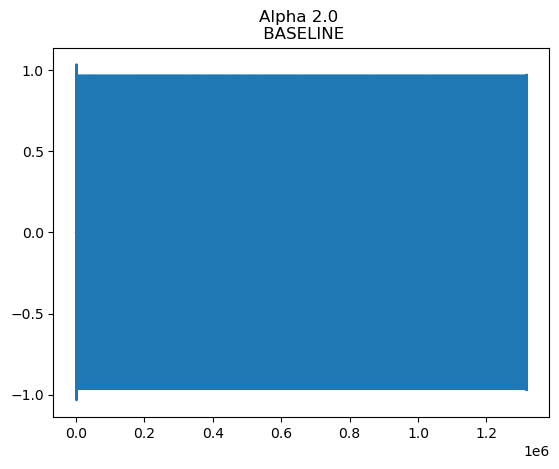

In [96]:
plt.plot(np.concatenate(baseline_output))
plt.title(f"Alpha {alpha} \n BASELINE")
print(f"Max: {np.max(np.concatenate(baseline_output)[int(0.2e6):int(0.4e6)])}")
# plt.xlim(int(0.2e6), int(0.2e6) + 100)
plt.show()

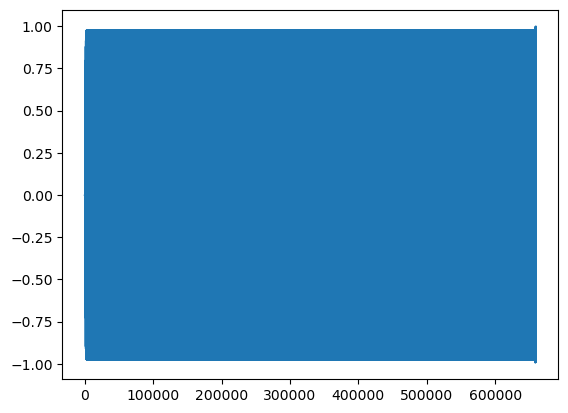

In [83]:
plt.plot(np.concatenate(lookup_output))
plt.show()

In [65]:
print(np.concatenate(lookup_output)[300000:300010])

[0.97462004 0.97462007 0.97462011 0.9746201  0.9746201  0.97462015
 0.97462014 0.97462017 0.97462017 0.97462019]


In [66]:
import random
# VOLUME COMPARISON WITH BASELINE
# # SIMPLE CASE: ARRAY OF ONES
frequency = 440
sample_rate = 22050
duration = 30.0  # 1 second
signal = np.ones(int(duration*sample_rate))

# # bin_idx = 41
# t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)
# signal = np.cos(2 * np.pi * frequency * t)

# # Randomly select a file from samples/genres_original/<genre>/<song>
# genres_dir = "samples/genres_original"
# genres = [g for g in os.listdir(genres_dir) if os.path.isdir(os.path.join(genres_dir, g))]
# chosen_genre = np.random.choice(genres)
# genre_path = os.path.join(genres_dir, chosen_genre)
# songs = [s for s in os.listdir(genre_path) if os.path.isfile(os.path.join(genre_path, s))]
# file_name = os.path.join(genre_path, np.random.choice(songs))

# file_name = '/Users/server/Documents/GitHub/DSP_FinalProject/samples/genres_original/pop/pop.00015.wav'
# audio_data, audio_sr = lb.load(file_name)
audio_data = signal
audio_sr = 22050

CHUNK = L = 2048
L_ola = 256
Hs = L // 4
Hs_ola = L_ola // 2
alpha = 1.5
window = scipy.signal.windows.hann(L, sym=False)
window_ola = scipy.signal.windows.hann(L_ola, sym=False)
output_buffer = np.zeros(int(L))
prev_fft = None
prev_phase = np.zeros(L//2 + 1)
omega_nom = np.arange(L//2 + 1) * 2 *np.pi * audio_sr / L
pos = 0
pos_ola = 0
baseline_output = []
Ha = 0
phases_in_baseline = []

while pos <= len(xh) - L:
    Ha = int(round(Hs/alpha))
    Ha_ola = int(round(Hs_ola/alpha))
    
    # start_time = time.perf_counter()

    # Phase Vocoder       
    # STFT processing
    pv_win = xh[pos:pos+L] * window
    S = np.fft.rfft(pv_win)
    magnitude = np.abs(S)
    # if prev_fft is not None:
    #     dphi = np.angle(S) - np.angle(prev_fft)
    #     dphi = dphi - omega_nom * (Ha/audio_sr)
    #     dphi = (dphi + np.pi) % (2*np.pi) - np.pi
    #     w_if = omega_nom + dphi * (audio_sr/Ha)
    #     prev_phase += w_if * (Hs/audio_sr)
    # else:
    #     prev_phase = np.angle(S)
    prev_phase = random.random()  # No phase continuity
    # phases_in_baseline.append(prev_phase[bin_idx]) # just the first bin for now
    # print(magnitude[0:10])
    X_mod = magnitude * np.exp(1j * prev_phase)
    pv_frame_mod = np.fft.irfft(X_mod)

    #shift and add to stream
    output_buffer[:-Hs] = output_buffer[Hs:]
    output_buffer[-Hs:] = 0
    output_buffer += pv_frame_mod * (window.reshape((-1, 1))/den.reshape((-1,1))).flatten()

    output_buffer = np.clip(output_buffer, -1.0, 1.0)  # FLoat range
    # To save
    baseline_output.append(output_buffer[:Hs].copy())

    # print(output_buffer)
    prev_fft = S
    # print(f"Baseline frame idx: {pos // Ha}")
    pos += Ha

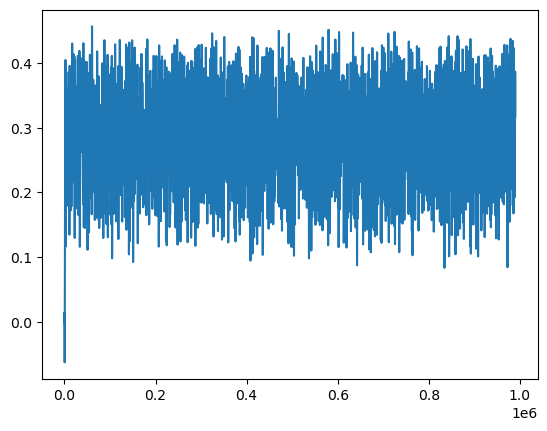

In [67]:
plt.plot(np.concatenate(baseline_output))

In [68]:
np.max(np.concatenate(baseline_output)[int(0.2*(10**6)):int(0.4*(10**6))])

0.4457403914223208

In [69]:
betas = ['0.25', '0.2', '0.15', '0.10']
vol_diff = [-1.6514654279855647,
            -3.257438412037424,
            -3.226927664446677,
            -3.1679570975043907]

voldiff_stdev = [0.5472648383959159,
                 0.2485860506200041,
                 0.26110203382916497,
                 0.2570790821511047]

mean_ratio = [0.8284000508076055,
              0.6875507005070304,
              0.690001451138253,
              0.6946920035256795
              ]

ratio_stdev = [0.04813261487114366,
               0.019481341109620794,
               0.020777284405933846,
               0.020566514395978047]

Text(0, 0.5, 'Volume Ratio ($\\frac{\\text{RMS}_\\text{lookup}}{\\text{RMS}_\\text{baseline}}$)')

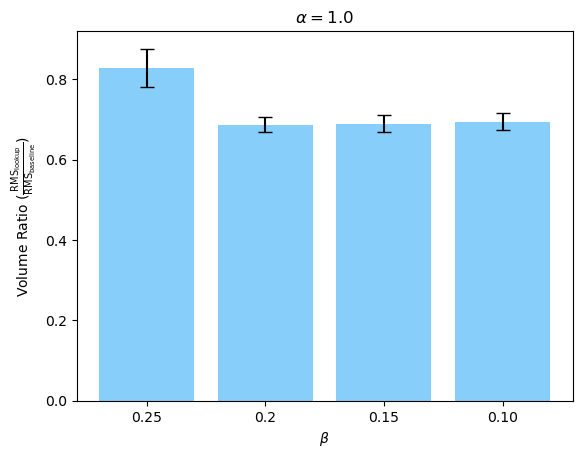

In [70]:
plt.bar(betas, mean_ratio, yerr=ratio_stdev, capsize=5, color='lightskyblue')
plt.xlabel(r"$\beta$")
plt.title(r"$\alpha = 1.0$")
plt.ylabel(r"Volume Ratio ($\frac{\text{RMS}_\text{lookup}}{\text{RMS}_\text{baseline}}$)")

Text(0, 0.5, 'Volume Ratio ($\\frac{\\text{RMS}_\\text{lookup}}{\\text{RMS}_\\text{baseline}}$)')

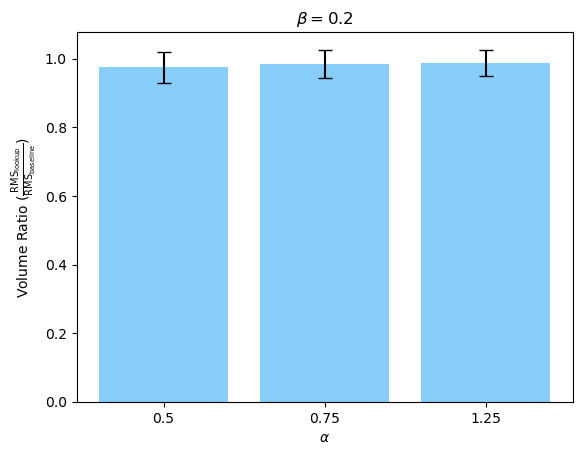

In [71]:
alphas = ['0.5', '0.75', '1.25']

vol_diff = [-0.22902115563453357,
            -0.13951945821177308,
            -0.11144010186813916
            ]

voldiff_stdev = [0.39516045006051237,
                 0.363682548481286,
                 0.3281196374239679,]

mean_ratio = [0.9749929651626615,
              0.9849279646995044,
              0.9879535074862735,
              ]

ratio_stdev = [0.0449086751499613,
               0.041255197382499026,
               0.03712135106703548]

plt.bar(alphas, mean_ratio, yerr=ratio_stdev, capsize=5, color='lightskyblue')
plt.title(r"$\beta = 0.2$")
plt.xlabel(r"$\alpha$")
plt.ylabel(r"Volume Ratio ($\frac{\text{RMS}_\text{lookup}}{\text{RMS}_\text{baseline}}$)")

Text(0, 0.5, 'Volume Ratio ($\\frac{\\text{RMS}_\\text{lookup}}{\\text{RMS}_\\text{baseline}}$)')

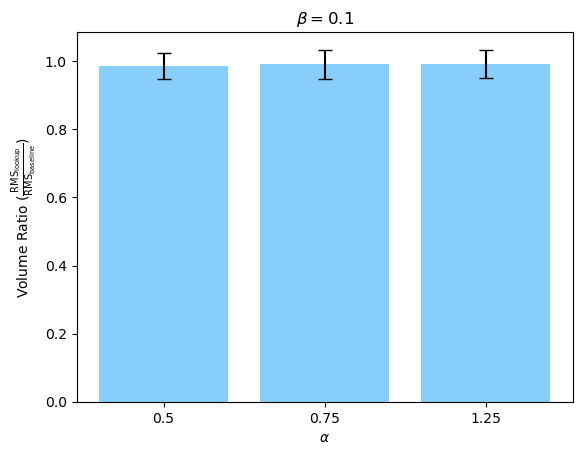

In [72]:
alphas = ['0.5', '0.75', '1.25']

vol_diff = [-0.13415138158762913,
            -0.08921360461439963,
            -0.08542432075627619
            ]

voldiff_stdev = [0.3414619898876453,
                 0.38038059452786416,
                 0.37400096211339523,]

mean_ratio = [0.985434865317508,
              0.9907256790831811,
              0.9911183517410738,
              ]

ratio_stdev = [0.03874532940448089,
               0.043070169494767926,
               0.041813060078664165]


plt.bar(alphas, mean_ratio, yerr=ratio_stdev, capsize=5, color='lightskyblue')
plt.title(r"$\beta = 0.1$")
plt.xlabel(r"$\alpha$")
plt.ylabel(r"Volume Ratio ($\frac{\text{RMS}_\text{lookup}}{\text{RMS}_\text{baseline}}$)")

In [73]:
betas = ['0.25', '0.2', '0.15', '0.10']
vol_diff = [-0.26211772681810475,
            -0.23044519493762014,
            -0.22188470127896323,
            -0.19684075682663654]

voldiff_stdev = [0.2840575596960332,
                 0.33041743357012243,
                 0.30078534206644697,
                 0.284621836090385]

mean_ratio = [0.9707898027083551,
              0.9745223641678755,
              0.9753619941797895,
              0.9781164995621598
              ]

ratio_stdev = [0.031524973679752544,
               0.03707115475377019,
               0.033733711076648076,
               0.03195874460949322]

Text(0, 0.5, 'Volume Ratio ($\\frac{\\text{RMS}_\\text{lookup}}{\\text{RMS}_\\text{baseline}}$)')

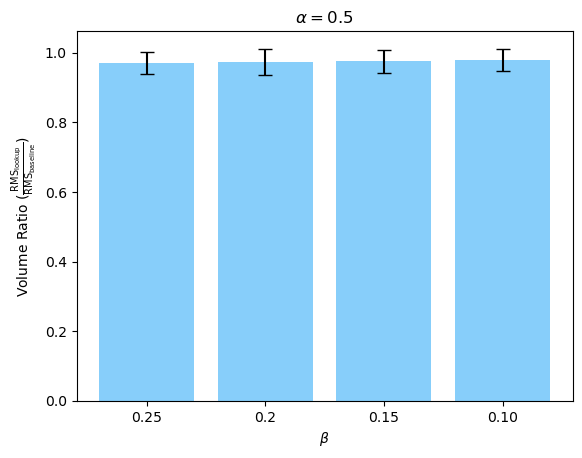

In [74]:
plt.bar(betas, mean_ratio, yerr=ratio_stdev, capsize=5, color='lightskyblue')
plt.title(r"$\alpha = 0.5$")
plt.xlabel(r"$\beta$")
plt.ylabel(r"Volume Ratio ($\frac{\text{RMS}_\text{lookup}}{\text{RMS}_\text{baseline}}$)")

Text(0, 0.5, 'Volume Ratio ($\\frac{\\text{RMS}_\\text{baseline}}{\\text{RMS}_\\text{origina}}$)')

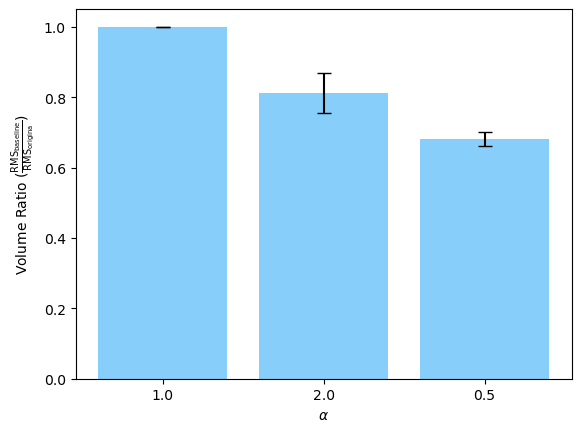

In [75]:
alphas = ['1.0', '2.0', '0.5']

mean_ratio = [1.0008408137381446,
              0.8120992556906763,
              0.681043250532414
              ]

ratio_stdev = [0.000245349864642268,
               0.0565479533345903,
               0.019749238556669314]
plt.bar(alphas, mean_ratio, yerr=ratio_stdev, capsize=5, color='lightskyblue')
plt.xlabel(r"$\alpha$")
plt.ylabel(r"Volume Ratio ($\frac{\text{RMS}_\text{baseline}}{\text{RMS}_\text{origina}}$)")